In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from prophet import Prophet

plt.style.use("seaborn-v0_8")
sns.set_palette("deep")
pd.set_option("display.max_columns", None)

In [18]:
# Load processed daily data
daily = pd.read_csv("../data/processed/daily_aggregated.csv")
daily["arrival_date"] = pd.to_datetime(daily["arrival_date"])

# Remove invalid values
daily = daily[(daily["daily_demand"] > 0) & (daily["avg_price"] > 0)]

daily.head()

,arrival_date,daily_demand,avg_price,month,day_of_week,is_weekend
0,2015-07-01,100,95.368300,7,2,0
1,2015-07-02,36,99.188611,7,3,0
2,2015-07-03,37,99.524054,7,4,0
3,2015-07-04,44,90.669091,7,5,1
4,2015-07-05,37,107.966486,7,6,1


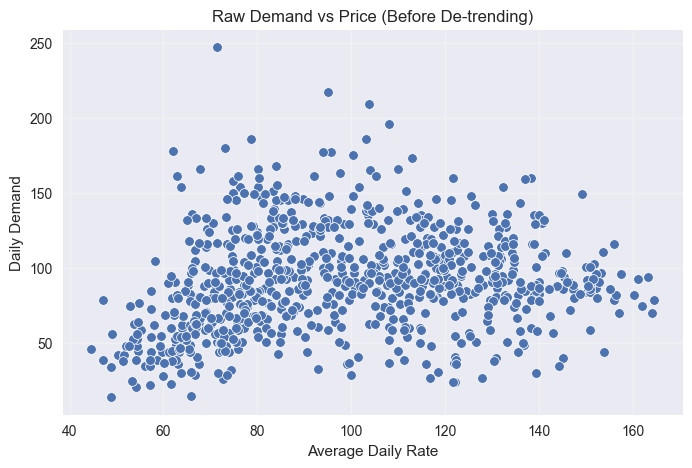

In [19]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="avg_price", y="daily_demand", data=daily)
plt.title("Raw Demand vs Price (Before De-trending)")
plt.xlabel("Average Daily Rate")
plt.ylabel("Daily Demand")
plt.grid(alpha=0.3)
plt.show()

In [20]:
# Prepare data for Prophet
prophet_df = daily.rename(
    columns={"arrival_date": "ds", "daily_demand": "y"}
)[["ds", "y"]]

model_prophet = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True
)

model_prophet.fit(prophet_df)

forecast = model_prophet.predict(prophet_df)

# Compute residual demand
daily["demand_residual"] = prophet_df["y"] - forecast["yhat"]

22:48:23 - cmdstanpy - INFO - Chain [1] start processing
22:48:23 - cmdstanpy - INFO - Chain [1] done processing


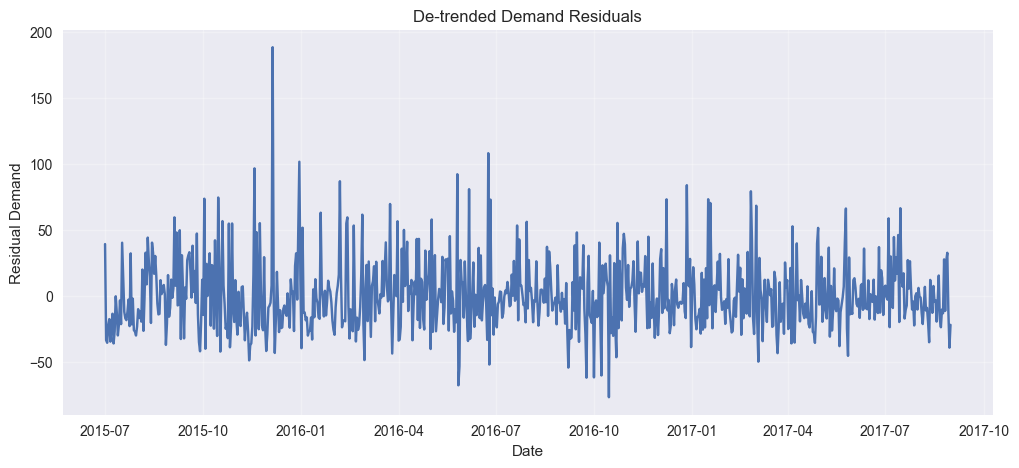

In [21]:
plt.figure(figsize=(12,5))
plt.plot(daily["arrival_date"], daily["demand_residual"])
plt.title("De-trended Demand Residuals")
plt.xlabel("Date")
plt.ylabel("Residual Demand")
plt.grid(alpha=0.3)
plt.show()

In [22]:
# Shift residuals to positive domain
shift_value = abs(daily["demand_residual"].min()) + 1
daily["adjusted_residual"] = daily["demand_residual"] + shift_value

daily = daily[daily["adjusted_residual"] > 0]

daily["log_residual_demand"] = np.log(daily["adjusted_residual"])
daily["log_price"] = np.log(daily["avg_price"])

In [23]:
X = daily[["log_price"]]
y = daily["log_residual_demand"]

model = LinearRegression()
model.fit(X, y)

elasticity = model.coef_[0]

print("De-trended Price Elasticity:", round(elasticity, 3))

De-trended Price Elasticity: -0.02


In [24]:
if elasticity < -1:
    interpretation = "Demand is elastic (high price sensitivity)."
elif -1 < elasticity < 0:
    interpretation = "Demand is inelastic (weak price sensitivity)."
else:
    interpretation = "Price impact is negligible after controlling for seasonality."

print(interpretation)

Demand is inelastic (weak price sensitivity).


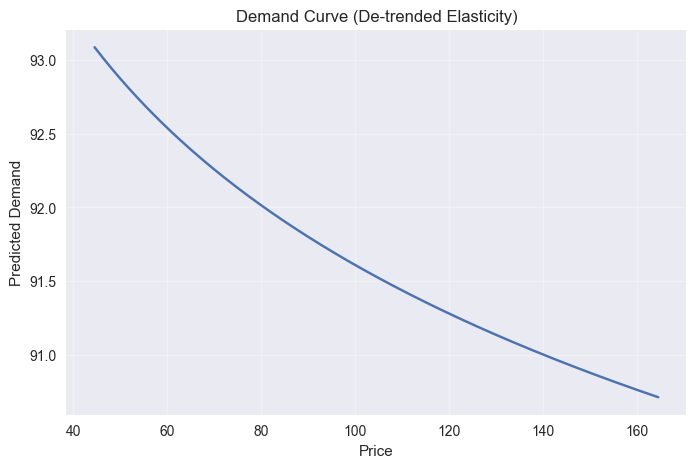

In [25]:
base_demand = daily["daily_demand"].mean()
reference_price = daily["avg_price"].mean()

def demand_function(price):
    return base_demand * (price / reference_price) ** elasticity

price_range = np.linspace(
    daily["avg_price"].min(),
    daily["avg_price"].max(),
    200
)

predicted_demand = demand_function(price_range)

plt.figure(figsize=(8,5))
plt.plot(price_range, predicted_demand)
plt.title("Demand Curve (De-trended Elasticity)")
plt.xlabel("Price")
plt.ylabel("Predicted Demand")
plt.grid(alpha=0.3)
plt.show()

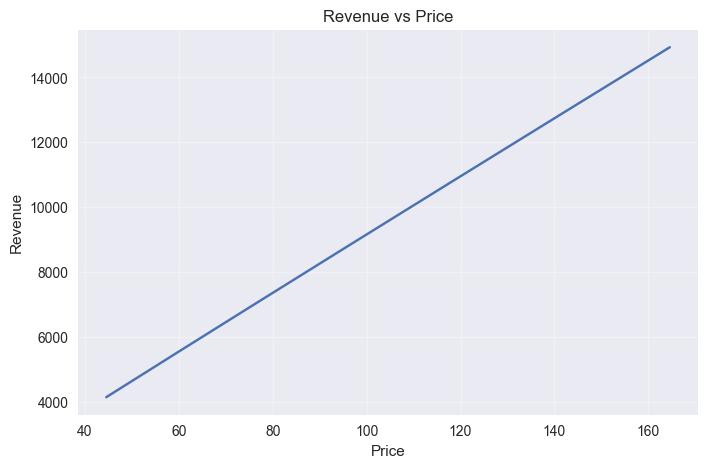

In [26]:
revenue = price_range * predicted_demand

plt.figure(figsize=(8,5))
plt.plot(price_range, revenue)
plt.title("Revenue vs Price")
plt.xlabel("Price")
plt.ylabel("Revenue")
plt.grid(alpha=0.3)
plt.show()

In [27]:
optimal_index = np.argmax(revenue)

optimal_price = price_range[optimal_index]
optimal_revenue = revenue[optimal_index]

print("Unconstrained Optimal Price:", round(optimal_price, 2))
print("Maximum Revenue:", round(optimal_revenue, 2))

Unconstrained Optimal Price: 164.59
Maximum Revenue: 14930.09
